In [139]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.13.0+cu130
True
NVIDIA GB10
NVIDIA GB10


In [140]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [141]:
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

In [142]:
ds.column_names

{'test': ['text'], 'train': ['text'], 'validation': ['text']}

In [143]:
print(ds['train'].features)
print(ds['train'].column_names)

{'text': Value(dtype='string', id=None)}
['text']


In [144]:
repr(ds['train'][:15])

'{\'text\': [\'\', \' = Valkyria Chronicles III = \\n\', \'\', \' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \\n\', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as maki

In [145]:
sum(1 for t in ds['train'][:1000]['text'] if t.strip().startswith("="))

175

In [146]:
def keep_row(example):
    text = example["text"].strip()
    return text != "" and not text.startswith("=")

ds = ds.filter(keep_row)

print(len(ds["train"]))   # expect ~17k, down from 36,718

17556


In [147]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [148]:
tokenizer.pad_token = tokenizer.eos_token

In [149]:
encoded_input = tokenizer("Knowledge distillation is fun")
encoded_input

{'input_ids': [23812, 2965, 1233, 40903, 318, 1257], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [150]:
tokenizer.tokenize("Knowledge distillation is fun")

['Know', 'ledge', 'Ġdist', 'illation', 'Ġis', 'Ġfun']

In [151]:
tokenizer.decode(encoded_input["input_ids"])

'Knowledge distillation is fun'

In [152]:
encoded_dataset = ds.map(lambda examples: tokenizer(examples["text"]), batched=True, remove_columns="text")

In [153]:
encoded_dataset["train"][0]

{'input_ids': [2311,
  73,
  13090,
  645,
  569,
  18354,
  7496,
  513,
  1058,
  791,
  47398,
  17740,
  357,
  4960,
  1058,
  10545,
  230,
  99,
  161,
  254,
  112,
  5641,
  44444,
  9202,
  25084,
  24440,
  12675,
  11839,
  18,
  837,
  6578,
  764,
  569,
  18354,
  7496,
  286,
  262,
  30193,
  513,
  1267,
  837,
  8811,
  6412,
  284,
  355,
  569,
  18354,
  7496,
  17740,
  6711,
  2354,
  2869,
  837,
  318,
  257,
  16106,
  2597,
  2488,
  12,
  31,
  2712,
  2008,
  983,
  4166,
  416,
  29490,
  290,
  6343,
  13,
  44206,
  329,
  262,
  14047,
  44685,
  764,
  28728,
  287,
  3269,
  2813,
  287,
  2869,
  837,
  340,
  318,
  262,
  2368,
  983,
  287,
  262,
  569,
  18354,
  7496,
  2168,
  764,
  12645,
  278,
  262,
  976,
  21748,
  286,
  16106,
  290,
  1103,
  2488,
  12,
  31,
  640,
  11327,
  355,
  663,
  27677,
  837,
  262,
  1621,
  4539,
  10730,
  284,
  262,
  717,
  983,
  290,
  5679,
  262,
  366,
  17871,
  5321,
  366,
  837,
  257,
  

In [154]:
block_size = 128

In [155]:
def group_texts(batch):
    concatenated = sum(batch["input_ids"], [])
    total_length = (len(concatenated) // block_size) * block_size
    blocks = []
    for i in range(0, total_length, block_size):
        blocks.append(concatenated[i : i + block_size])
    return {"input_ids": blocks, "labels": [b.copy() for b in blocks]}

In [156]:
lm_dataset = encoded_dataset.map(
    group_texts,
    batched=True,
    remove_columns=encoded_dataset["train"].column_names,
)

In [157]:
print(len(lm_dataset["train"]))              # how many blocks? (~16k?)
print(len(lm_dataset["train"][0]["input_ids"]))   # should be exactly 128

18200
128


In [158]:
tokenizer.decode(lm_dataset["train"][0]["input_ids"])

' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3, lit. Valkyria of the Battlefield 3 ), commonly referred to as Valkyria Chronicles III outside Japan, is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable. Released in January 2011 in Japan, it is the third game in the Valkyria series. Employing the same fusion of tactical and real @-@ time gameplay as its predecessors, the story runs parallel to the first game and follows the " Nameless ",'

In [159]:
teacher = AutoModelForCausalLM.from_pretrained("openai-community/gpt2-medium")

In [160]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [161]:
teacher.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [162]:
for p in teacher.parameters():
    p.requires_grad = False

In [163]:
teacher = teacher.to(device)

In [164]:
next(teacher.parameters()).device

device(type='cuda', index=0)

In [165]:
# rough shape check
out = teacher(torch.tensor([lm_dataset["train"][0]["input_ids"]]).to(device))
out.logits.shape

torch.Size([1, 128, 50257])

In [166]:
student = AutoModelForCausalLM.from_pretrained("distilbert/distilgpt2") 

In [167]:
student = student.to(device)

In [168]:
next(teacher.parameters()).device

device(type='cuda', index=0)

In [169]:
print("Number of parameters in teacher:", sum(p.numel() for p in teacher.parameters()))
print("Number of parameters in student:", sum(p.numel() for p in student.parameters()))

Number of parameters in teacher: 354823168
Number of parameters in student: 81912576


### Distillation Training

In [170]:
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = optim.Adam(student.parameters(), lr=1e-5)

In [171]:
# 1. tell the dataset to hand back torch tensors (only these two columns)
lm_dataset.set_format("torch", columns=["input_ids", "labels"])

# 2. make the loader that yields batches
train_loader = DataLoader(lm_dataset["train"], batch_size=64, shuffle=True)

### Setting up training loop

In [172]:
def distill(student, teacher, loader, val_loader, epochs=30):
    train_losses, val_perplexities = [], []
    best_ppl, best_ep = float("inf"), 0
    for ep in range(epochs):
        student.train()
        total_loss = 0
        for batch in loader:
            inputs = batch["input_ids"].to(device)
            true_answers = batch["labels"].to(device)
            

            # --- CHANGE 1: run the model forwards in bf16 (faster on your GB10) ---
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                with torch.no_grad():
                    t_logits = teacher(inputs).logits
                s_logits = student(inputs).logits

            # --- CHANGE 2: cast back to fp32 for the loss math ---
            t_logits = t_logits.float()
            s_logits = s_logits.float()

            t_probs = torch.softmax(t_logits / temperature, dim=-1)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=-1)
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits[:, :-1, :].reshape(-1, s_logits.size(-1)),
                                true_answers[:, 1:].reshape(-1))
            loss = alpha * loss_soft + (1 - alpha) * loss_hard
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        val_ppl = perplexity(student, val_loader)      # ← the early-stopping signal
        train_losses.append(avg_loss)
        val_perplexities.append(val_ppl)

        if val_ppl < best_ppl:
            best_ppl, best_ep = val_ppl, ep + 1
            marker = "  <-- best so far"
        else:
            marker = "  ^ worse (overfitting?)"
        print(f"Epoch {ep+1:2d} | train loss {avg_loss:8.2f} | val ppl {val_ppl:7.2f}{marker}")

    print(f"\nBest validation perplexity: {best_ppl:.2f} at epoch {best_ep}")
    return train_losses, val_perplexities

In [173]:
import math

def perplexity(model, loader):
    model.eval()
    total_loss = 0
    count = 0
    with torch.no_grad():
        for batch in loader:
            inputs = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            out = model(inputs, labels=labels)
            total_loss += out.loss.item()
            count += 1
    return math.exp(total_loss / count)

In [174]:
val_loader = DataLoader(lm_dataset["validation"], batch_size=64)   # no shuffle for eval

In [175]:
train_losses, val_perplexities = distill(student, teacher, train_loader, val_loader, epochs=30)

Epoch  1 | train loss    96.96 | val ppl   68.57  <-- best so far
Epoch  2 | train loss    91.92 | val ppl   66.53  <-- best so far
Epoch  3 | train loss    89.69 | val ppl   65.66  <-- best so far
Epoch  4 | train loss    88.01 | val ppl   64.87  <-- best so far
Epoch  5 | train loss    86.69 | val ppl   64.27  <-- best so far
Epoch  6 | train loss    85.57 | val ppl   63.51  <-- best so far
Epoch  7 | train loss    84.59 | val ppl   63.38  <-- best so far
Epoch  8 | train loss    83.68 | val ppl   63.32  <-- best so far
Epoch  9 | train loss    82.87 | val ppl   62.99  <-- best so far
Epoch 10 | train loss    82.11 | val ppl   62.74  <-- best so far
Epoch 11 | train loss    81.41 | val ppl   62.45  <-- best so far
Epoch 12 | train loss    80.79 | val ppl   62.32  <-- best so far
Epoch 13 | train loss    80.15 | val ppl   62.13  <-- best so far
Epoch 14 | train loss    79.60 | val ppl   61.97  <-- best so far
Epoch 15 | train loss    79.04 | val ppl   62.05  ^ worse (overfitting?)
Epo

In [176]:
print("Student:", perplexity(student, val_loader))
print("Teacher:", perplexity(teacher, val_loader))

Student: 60.77382204141532
Teacher: 42.70304358198359


In [177]:
def token_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            inputs = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            logits = model(inputs).logits              # [batch, seq, vocab]
            preds = logits[:, :-1, :].argmax(dim=-1)    # model's top next-token guess
            targets = labels[:, 1:]                     # the actual next token
            correct += (preds == targets).sum().item()  # count the matches
            total += targets.numel()                    # count all positions
    return correct / total * 100

In [178]:
print("Student:", token_accuracy(student, val_loader))
print("Teacher:", token_accuracy(teacher, val_loader))

Student: 29.217953760030795
Teacher: 33.64949333511845


In [179]:
prompt = "The meaning of life is"

In [180]:
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

In [181]:
output_student = student.generate(
    input_ids,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    pad_token_id=tokenizer.eos_token_id,
)

In [182]:
output_teacher = teacher.generate(
    input_ids,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    pad_token_id=tokenizer.eos_token_id,
)

In [183]:
print(tokenizer.decode(output_student[0], skip_special_tokens=True))
print()
print()
print(tokenizer.decode(output_teacher[0], skip_special_tokens=True))

The meaning of life is a little different. Not all good, but some of the better in the world.
As one of the most well-known examples of the concept of truth, this may also be interpreted as a


The meaning of life is very well explained in the Bible, but I think that God really cares about people. He does not put things in the order that he wants them to be, and if he does, we've got


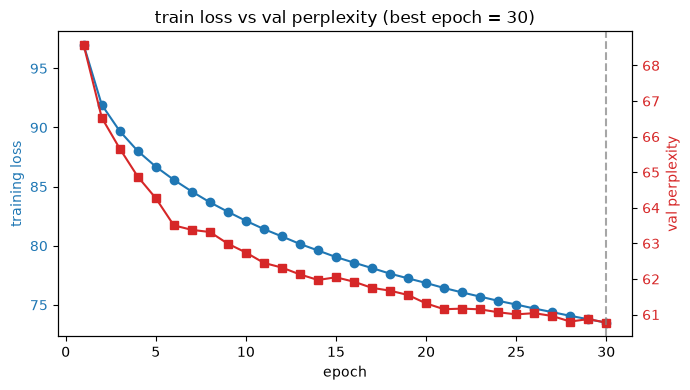

In [184]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)
best_ep = val_perplexities.index(min(val_perplexities)) + 1

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs_range, train_losses, "o-", color="tab:blue", label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("training loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(epochs_range, val_perplexities, "s-", color="tab:red", label="val perplexity")
ax2.set_ylabel("val perplexity", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax2.axvline(best_ep, ls="--", color="gray", alpha=0.7)
plt.title(f"train loss vs val perplexity (best epoch = {best_ep})")
fig.tight_layout(); plt.show()

In [185]:
fresh = AutoModelForCausalLM.from_pretrained("distilbert/distilgpt2").to(device)
print("Fresh distilgpt2 (no training):", perplexity(fresh, val_loader))

Fresh distilgpt2 (no training): 85.42843390893962


In [186]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [187]:
torch.save(student.state_dict(), "distilled_student_30ep.pth")